## Appendix 1: Code and Output

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings

# Modeling libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Model evaluation libraries
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, roc_auc_score, accuracy_score
from sklearn.inspection import permutation_importance
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy import stats
from scipy.stats import zscore

warnings.filterwarnings('ignore')

In [2]:
# Importing the Titanic dataset
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
passenger_id = test_df["PassengerId"]

### 1. Exploratory Data Analysis

In [3]:
# Dataset overview
dataset_info = pd.DataFrame({
    'Dataset': ['Training', 'Test'],
    'Rows': [train_df.shape[0], test_df.shape[0]],
    'Columns': [train_df.shape[1], test_df.shape[1]]
})

print("Dataset Overview:")
display(dataset_info)

data_types_summary = pd.DataFrame({
    'Data_Type': train_df.dtypes.value_counts().index,
    'Count': train_df.dtypes.value_counts().values
})
print("Data Types Summary in Training Dataset:")
display(data_types_summary)

# Missing values analysis
missing_values = pd.DataFrame({
    'Column': train_df.columns,
    'Missing_Count': train_df.isnull().sum().values,
    'Missing_Percentage': (train_df.isnull().sum() / len(train_df) * 100).values
})
print("Missing Values in Training Dataset:")
display(missing_values)

Dataset Overview:


,Dataset,Rows,Columns
0,Training,891,12
1,Test,418,11


Data Types Summary in Training Dataset:


,Data_Type,Count
0,int64,5
1,object,5
2,float64,2


Missing Values in Training Dataset:


,Column,Missing_Count,Missing_Percentage
0,PassengerId,0,0.000000
1,Survived,0,0.000000
2,Pclass,0,0.000000
3,Name,0,0.000000
4,Sex,0,0.000000
5,Age,177,19.865320
6,SibSp,0,0.000000
7,Parch,0,0.000000
8,Ticket,0,0.000000
9,Fare,0,0.000000


In [4]:
# Survival rate analysis
survival_stats = pd.DataFrame({
    'Metric': ['Total Passengers', 'Survived', 'Died', 'Survival Rate'],
    'Value': [len(train_df), train_df['Survived'].sum(), 
              len(train_df) - train_df['Survived'].sum(),
              f"{train_df['Survived'].mean():.2%}"]
})
print("Survival Statistics:")
display(survival_stats)

Survival Statistics:


,Metric,Value
0,Total Passengers,891
1,Survived,342
2,Died,549
3,Survival Rate,38.38%


Of the 891 passengers in our training dataset, we note that only 342 (~40%) survived the disaster.

#### 1.1 Visualization

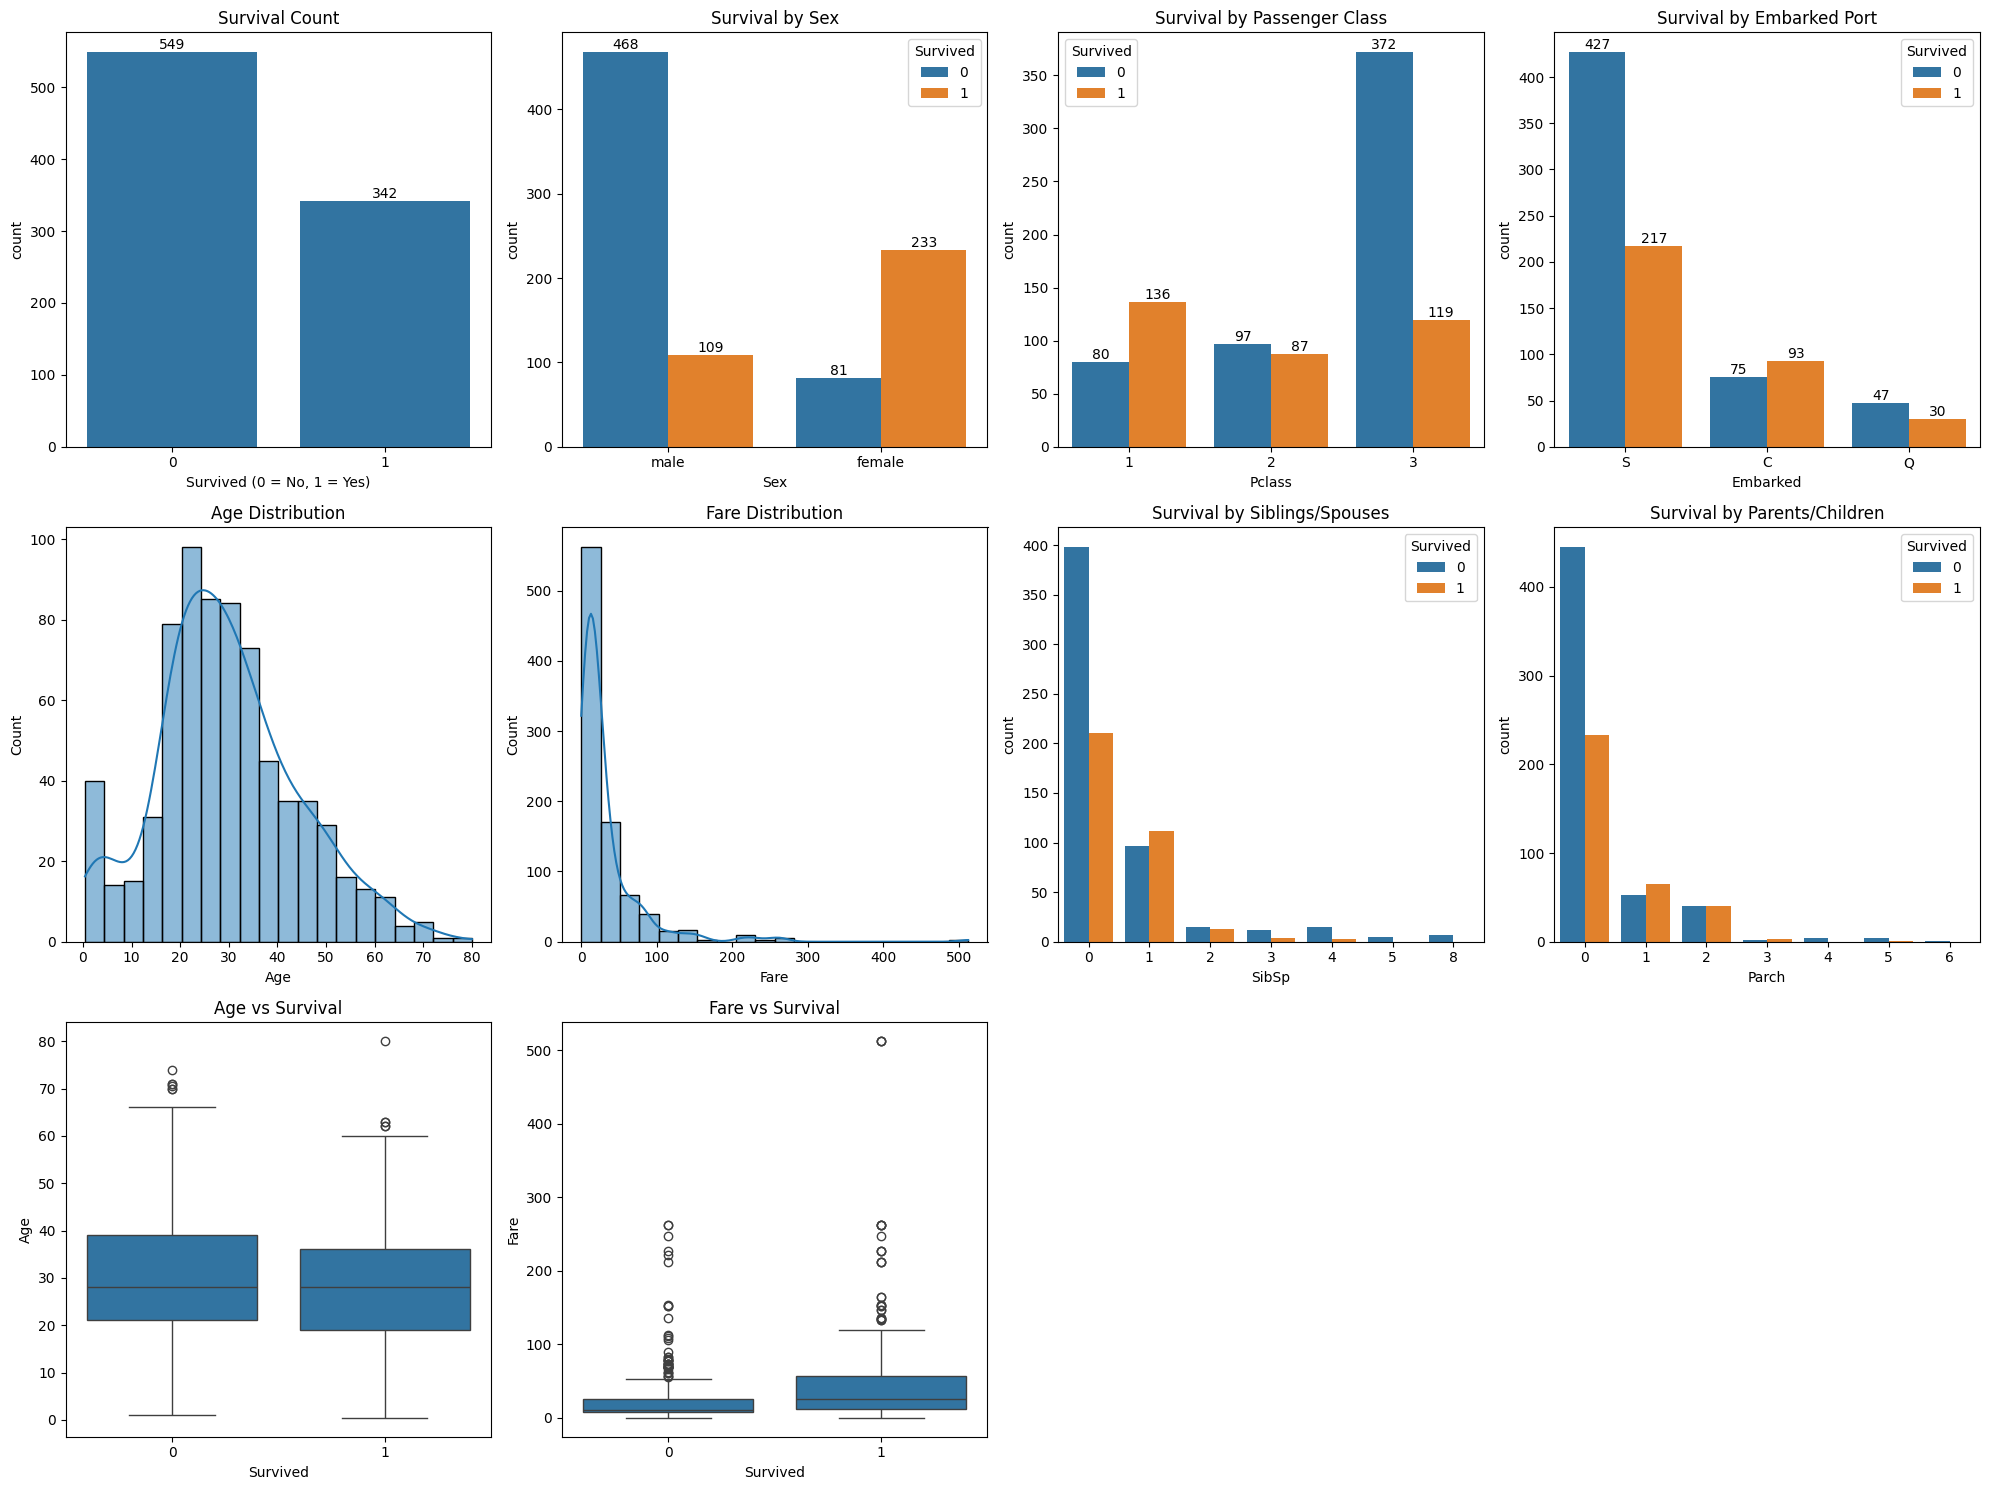

In [5]:
# Visualization
plt.figure(figsize=(20, 15))

# 1. Survival Count
plt.subplot(3, 4, 1)
ax1 = sns.countplot(x='Survived', data=train_df)
for p in ax1.patches:
    count = int(p.get_height())
    if count > 0:
        ax1.annotate(str(count), (p.get_x() + p.get_width() / 2., count), 
                     ha='center', va='bottom', fontsize=10)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")

# 2. Survival by Sex
plt.subplot(3, 4, 2)
ax2 = sns.countplot(x='Sex', hue='Survived', data=train_df)
for p in ax2.patches:
    count = int(p.get_height())
    if count > 0:
        ax2.annotate(str(count), (p.get_x() + p.get_width() / 2., count), 
                     ha='center', va='bottom', fontsize=10)
plt.title("Survival by Sex")

# 3. Survival by Passenger Class
plt.subplot(3, 4, 3)
ax3 = sns.countplot(x='Pclass', hue='Survived', data=train_df)
for p in ax3.patches:
    count = int(p.get_height())
    if count > 0:
        ax3.annotate(str(count), (p.get_x() + p.get_width() / 2., count), 
                     ha='center', va='bottom', fontsize=10)
plt.title("Survival by Passenger Class")

# 4. Embarked vs Survival
plt.subplot(3, 4, 4)
ax4 = sns.countplot(x='Embarked', hue='Survived', data=train_df)
for p in ax4.patches:
    count = int(p.get_height())
    if count > 0:
        ax4.annotate(str(count), (p.get_x() + p.get_width() / 2., count), 
                     ha='center', va='bottom', fontsize=10)
plt.title("Survival by Embarked Port")

# 5. Age Distribution
plt.subplot(3, 4, 5)
sns.histplot(train_df['Age'], bins=20, kde=True)
plt.title("Age Distribution")

# 6. Fare Distribution
plt.subplot(3, 4, 6)
sns.histplot(train_df['Fare'], bins=20, kde=True)
plt.title("Fare Distribution")

# 7. Survival by SibSp
plt.subplot(3, 4, 7)
sns.countplot(x='SibSp', hue='Survived', data=train_df)
plt.title("Survival by Siblings/Spouses")

# 8. Survival by Parch
plt.subplot(3, 4, 8)
sns.countplot(x='Parch', hue='Survived', data=train_df)
plt.title("Survival by Parents/Children")

# 9. Age vs Survival
plt.subplot(3, 4, 9)
sns.boxplot(x='Survived', y='Age', data=train_df)
plt.title("Age vs Survival")

# 10. Fare vs Survival
plt.subplot(3, 4, 10)
sns.boxplot(x='Survived', y='Fare', data=train_df)
plt.title("Fare vs Survival")

plt.tight_layout()
plt.show()

In [6]:
for col in train_df.select_dtypes(include=['object']).columns:
    print(f"Unique values in '{col}': {train_df[col].nunique()}")

Unique values in 'Name': 891
Unique values in 'Sex': 2
Unique values in 'Ticket': 681
Unique values in 'Cabin': 147
Unique values in 'Embarked': 3


Our general understanding is that `PassengerId`, `Name`, `Ticket` and `Cabin` features do not have an impact on survival status. Therefore, we will be dropping them from further evaluation

In [7]:
train_df = train_df.drop(['PassengerId', 'Cabin', 'Name', 'Ticket'], axis=1)
test_df = test_df.drop(['PassengerId', 'Cabin', 'Name', 'Ticket'], axis=1)

Text(0.5, 1.0, 'Correlation Matrix')

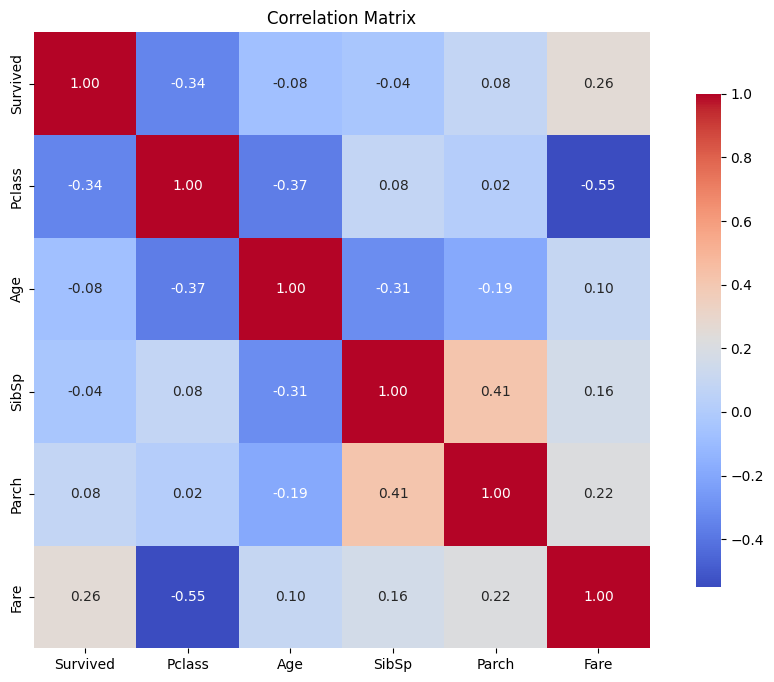

In [8]:
# Correlation Matrix
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 8))
correlation_matrix = train_df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix")

### 2. Feature Engineering

We have missing values in `Age` & `Embarked` columns. We will impute the `Age` using the median, `Fare` using the median by passenger class and the `Embarked` detail with `S` = `Southampton` since it is the most frequent value.

In [9]:
# Impute missing Age values using the median Age for each Pclass
train_df['Age'] = train_df['Age'].transform(lambda x: x.fillna(x.median()))
train_df['Fare'] = train_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
train_df['Embarked'] = train_df['Embarked'].fillna('S')

# Impute missing Age values in test set
test_df['Age'] = test_df['Age'].transform(lambda x: x.fillna(x.median()))
test_df['Fare'] = test_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
test_df['Embarked'] = test_df['Embarked'].fillna('S')

Missing values are now zero across the datasets. Now, we will convert categorical values into numeric values by encoding each unique value

In [10]:
# Convert categorical variables to numerical by mapping features
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].fillna('S')
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
train_df['Fare'] = train_df['Fare'].fillna(train_df['Fare'].median())
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df['Embarked'] = test_df['Embarked'].fillna('S')
test_df['Embarked'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

In [11]:
# Adding FamilySize feature that is created by summing the number of siblings/spouses (SibSp) and parents/children (Parch) aboard, plus one for the individual themselves.
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df = train_df.drop(['SibSp', 'Parch'], axis=1) # Drop SibSp and Parch as they are now redundant

test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df = test_df.drop(['SibSp', 'Parch'], axis=1) # Drop SibSp and Parch as they are now redundant

In [12]:
# Missing values
print("Are there any missing values in the dataset?")
print("Training Dataset:", train_df.isnull().values.any())
print("Test Dataset:", test_df.isnull().values.any())

Are there any missing values in the dataset?
Training Dataset: False
Test Dataset: False


In [13]:
# Display the data types of the columns
print("Data Types of Training Dataset:")
print(train_df.dtypes)
print("\nData Types of Test Dataset:")
print(test_df.dtypes)

Data Types of Training Dataset:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
Embarked        int64
FamilySize      int64
dtype: object

Data Types of Test Dataset:
Pclass          int64
Sex             int64
Age           float64
Fare          float64
Embarked        int64
FamilySize      int64
dtype: object


All selected features are now numeric. 

### 3. Modeling

In [14]:
# Creating feature set X and target variable y
X = train_df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']]
y = train_df['Survived']
X_test = test_df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']]

In [15]:
# Scaling Age, Fare and FamilySize as they are continuous variables
scaler = StandardScaler()
X[['Age', 'Fare', 'FamilySize']] = scaler.fit_transform(X[['Age', 'Fare', 'FamilySize']]) 
X_test[['Age', 'Fare', 'FamilySize']] = scaler.transform(X_test[['Age', 'Fare', 'FamilySize']])

In [16]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### 3.1 Logistic Regression

In [17]:
model_log = LogisticRegression(max_iter=100)

tprs_log, fprs_log, precs_log, recs_log, accs_log, aucs_log = [], [], [], [], [], []

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_log.fit(X_train, y_train)
    y_pred = model_log.predict(X_val)
    y_proba = model_log.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    tprs_log.append(tp / (tp + fn))
    fprs_log.append(fp / (fp + tn))
    precs_log.append(tp / (tp + fp) if tp + fp else 0)
    recs_log.append(tp / (tp + fn) if tp + fn else 0)
    accs_log.append(accuracy_score(y_val, y_pred))
    aucs_log.append(roc_auc_score(y_val, y_proba))

fpr_log, tpr_log, _ = roc_curve(y, model_log.predict_proba(X)[:, 1])
prec_log, rec_log, _ = precision_recall_curve(y, model_log.predict_proba(X)[:, 1])

#### 3.2 Quadratic Discriminant Analysis

In [18]:
model_qda = QuadraticDiscriminantAnalysis()
tprs_qda, fprs_qda, precs_qda, recs_qda, accs_qda, aucs_qda = [], [], [], [], [], []

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_qda.fit(X_train, y_train)
    y_pred = model_qda.predict(X_val)
    y_proba = model_qda.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    tprs_qda.append(tp / (tp + fn))
    fprs_qda.append(fp / (fp + tn))
    precs_qda.append(tp / (tp + fp) if tp + fp else 0)
    recs_qda.append(tp / (tp + fn) if tp + fn else 0)
    accs_qda.append(accuracy_score(y_val, y_pred))
    aucs_qda.append(roc_auc_score(y_val, y_proba))

fpr_qda, tpr_qda, _ = roc_curve(y, model_qda.predict_proba(X)[:, 1])
prec_qda, rec_qda, _ = precision_recall_curve(y, model_qda.predict_proba(X)[:, 1])

#### 3.3 K-Nearest Neighbors

Optimal k: 9
Best CV accuracy: 0.8081


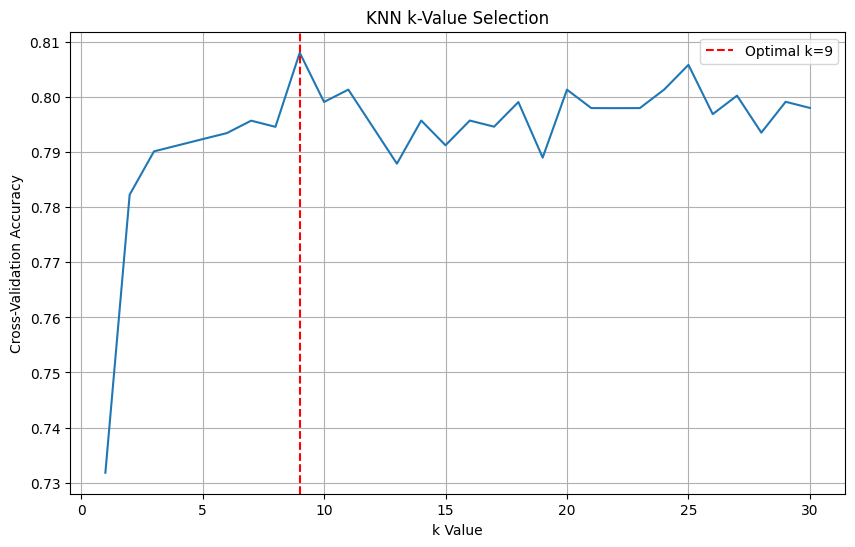

Optimal k=9


In [19]:
k_range = range(1, 31)
k_scores = []
for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X, y, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

optimal_k = k_range[np.argmax(k_scores)]
print(f"Optimal k: {optimal_k}")
print(f"Best CV accuracy: {max(k_scores):.4f}")

# Plot k selection
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores)
plt.xlabel('k Value')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN k-Value Selection')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.legend()
plt.grid(True)
plt.show()

# Printing optimal k
print(f"Optimal k={optimal_k}")

In [20]:
model_knn = KNeighborsClassifier(n_neighbors=optimal_k)
tprs_knn, fprs_knn, precs_knn, recs_knn, accs_knn, aucs_knn = [], [], [], [], [], []

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_knn.fit(X_train, y_train)
    y_pred = model_knn.predict(X_val)
    y_proba = model_knn.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    tprs_knn.append(tp / (tp + fn))
    fprs_knn.append(fp / (fp + tn))
    precs_knn.append(tp / (tp + fp) if tp + fp else 0)
    recs_knn.append(tp / (tp + fn) if tp + fn else 0)
    accs_knn.append(accuracy_score(y_val, y_pred))
    aucs_knn.append(roc_auc_score(y_val, y_proba))

fpr_knn, tpr_knn, _ = roc_curve(y, model_knn.predict_proba(X)[:, 1])
prec_knn, rec_knn, _ = precision_recall_curve(y, model_knn.predict_proba(X)[:, 1])

### 4. Results

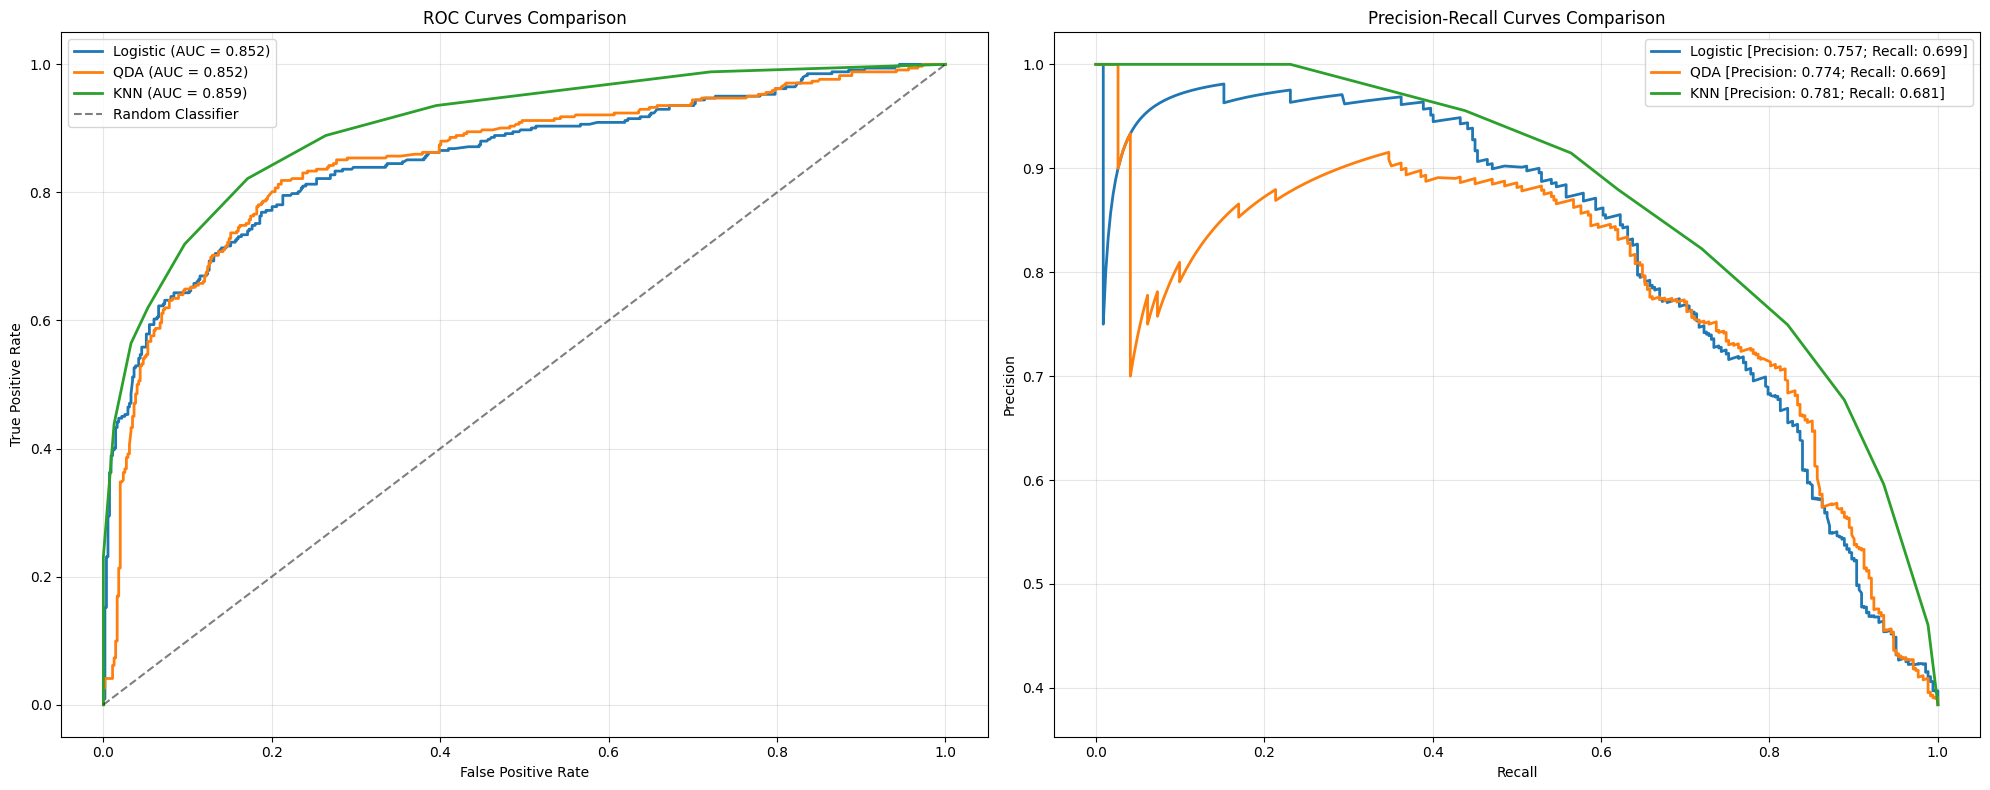

In [21]:
plt.figure(figsize=(20, 8))

# ROC Curves
plt.subplot(1, 2, 1)
plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC = {np.mean(aucs_log):.3f})', linewidth=2)
plt.plot(fpr_qda, tpr_qda, label=f'QDA (AUC = {np.mean(aucs_qda):.3f})', linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {np.mean(aucs_knn):.3f})', linewidth=2)
# Add diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

# Precision-Recall Curves
plt.subplot(1, 2, 2)
plt.plot(rec_log, prec_log, label=f'Logistic [Precision: {np.mean(precs_log):.3f}; Recall: {np.mean(recs_log):.3f}]', linewidth=2)
plt.plot(rec_qda, prec_qda, label=f'QDA [Precision: {np.mean(precs_qda):.3f}; Recall: {np.mean(recs_qda):.3f}]', linewidth=2)
plt.plot(rec_knn, prec_knn, label=f'KNN [Precision: {np.mean(precs_knn):.3f}; Recall: {np.mean(recs_knn):.3f}]', linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of results**<br>

ROC Curve:
- This tells us how well our model can differentiate between 'survivors' and 'non-survivors'
- A model can tell the difference between these groups well if its AUC value is close to 1.0. 
- All models do well because their AUC scores are over 85%.

Precision-Recall Curve:
- This measures how each model performs on imbalanced data (more non-survivors than survivors)
- The higher the curves, the better the model is at precision-recall trade-offs
- All models are comparable in performance, though Logistic Regression has the best recall and KNN has the best precision

In [22]:
# Storing results
models_results = {}

models_results['Logistic Regression'] = {
    'TPR': np.mean(tprs_log),
    'FPR': np.mean(fprs_log),
    'Precision': np.mean(precs_log),
    'Recall': np.mean(recs_log),
    'Accuracy': np.mean(accs_log),
    'AUC': np.mean(aucs_log)
}

models_results['QDA'] = {
    'TPR': np.mean(tprs_qda),
    'FPR': np.mean(fprs_qda),
    'Precision': np.mean(precs_qda),
    'Recall': np.mean(recs_qda),
    'Accuracy': np.mean(accs_qda),
    'AUC': np.mean(aucs_qda)
}

models_results['KNN'] = {
    'TPR': np.mean(tprs_knn),
    'FPR': np.mean(fprs_knn),
    'Precision': np.mean(precs_knn),
    'Recall': np.mean(recs_knn),
    'Accuracy': np.mean(accs_knn),
    'AUC': np.mean(aucs_knn)
}

comparison_df = pd.DataFrame(models_results).T
comparison_df = comparison_df.round(3)
display(comparison_df)

,TPR,FPR,Precision,Recall,Accuracy,AUC
Logistic Regression,0.699,0.140,0.757,0.699,0.798,0.852
QDA,0.669,0.122,0.774,0.669,0.798,0.852
KNN,0.681,0.122,0.781,0.681,0.802,0.859


### 5. Model Evaluation

#### 5.1 Logistic Regression

1. **What we check**: We test if the relationship between each continuous feature and survival is smooth and consistent (called “linearity of the logit”).

2. **Why it matters**: The model assumes that changes in features (like Age or Fare) have a steady, predictable effect on the chance of survival (on a log scale). If this is not true, the model’s predictions can be misleading.

3. **How we check it**: Using statistical tests (like Box-Tidwell) or simple plots to confirm the relationship is close to straight, not curved or weird.

4. *Other checks*:

    a. Features should not be too similar to each other (to avoid confusion in the model).

    b. Each passenger’s survival outcome should be independent (one doesn’t affect another and there are no unusual data points that could distort results.)

In [23]:
print("1. Linearity of logit (Box-Tidwell test):")
# Box-Tidwell test for linearity of logit
X_bt = X.copy()

# Add interaction terms for continuous features
X_bt['Age_log_int'] = X_bt['Age'] * np.log1p(X_bt['Age'])
X_bt['Age_log_int'] = X_bt['Age_log_int'].fillna(X_bt['Age_log_int'].median())
X_bt['Fare_log_int'] = X_bt['Fare'] * np.log1p(X_bt['Fare'])
X_bt['FamilySize_log_int'] = X_bt['FamilySize'] * np.log1p(X_bt['FamilySize'])

# Add intercept for statsmodels
X_bt_const = sm.add_constant(X_bt)

# Fit logistic regression model
logit_model_bt = sm.Logit(y, X_bt_const).fit()
print(logit_model_bt.summary())

1. Linearity of logit (Box-Tidwell test):
Optimization terminated successfully.
         Current function value: 0.435335
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      881
Method:                           MLE   Df Model:                            9
Date:                Sun, 20 Jul 2025   Pseudo R-squ.:                  0.3463
Time:                        13:25:15   Log-Likelihood:                -387.88
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 6.500e-83
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.1071      0.378      2.92

The test confirms that the relationship between age, fare, and family size with survival is generally smooth and predictable. This means our model's assumptions are reasonable, so its predictions about who survived are trustworthy.

In [24]:
print("2. Multicollinearity (Variance Inflation Factor):")
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

2. Multicollinearity (Variance Inflation Factor):
      feature       VIF
0      Pclass  1.786395
1         Sex  1.556143
2         Age  1.099673
3        Fare  1.221483
4    Embarked  1.387202
5  FamilySize  1.176519


None of the features in our model are too similar to each other (usually denoted by VIF > 5), meaning each features is useful for predicting survival. This helps ensure our predictions are reliable and not distorted by overlapping data.

In [25]:
print("3. Independence of observations (Cook's distance):")
influence = logit_model_bt.get_influence()
summary_frame = influence.summary_frame()
print(summary_frame[['cooks_d', 'standard_resid']].sort_values(by='cooks_d', ascending=False).head())

3. Independence of observations (Cook's distance):
      cooks_d  standard_resid
737  0.057180        0.982856
679  0.039533        0.845677
630  0.039474        3.343032
68   0.030098        2.190103
261  0.027464        5.532179


In [26]:
print("\n4. Durbin-Watson test for independence (residuals):")

# Get residuals from the model
residuals = logit_model_bt.resid_pearson
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")
print(f"Interpretation: {'No autocorrelation' if 1.5 < dw_stat < 2.5 else 'Potential autocorrelation'}")
print("Values close to 2 indicate independence of observations")


4. Durbin-Watson test for independence (residuals):
Durbin-Watson statistic: 1.9839
Interpretation: No autocorrelation
Values close to 2 indicate independence of observations


Most passengers in our data do not have an outsized influence on the model’s predictions, meaning no single person’s information is distorting the results. A few passengers stand out as unusual, but overall, the model’s conclusions are stable and trustworthy.

#### 5.2 Quadratic Discriminant Analysis (QDA)

1. **What we check**: Each class should have normally distributed features, and we need sufficient data to estimate separate covariance matrices for each class.

2. **Why it matters**: QDA assumes multivariate normality within each class and estimates separate covariance structures. Unlike LDA, it doesn't assume equal covariances between classes.

3. **How we check it**: Q-Q plots and normality tests (Shapiro-Wilk) for each feature by class, plus sample size adequacy (typically need p(p+1)/2 samples per class where p = number of features).

4. **Other checks**: Independence of observations, no severe multicollinearity, and adequate sample sizes for stable covariance estimation.

In [27]:
print("1. Check sample sizes for covariance estimation\n")

# Split features by class
group0 = X[y == 0]
group1 = X[y == 1]

n_features = X.shape[1]
min_samples_needed = (n_features * (n_features + 1)) // 2

print(f"Number of features: {n_features}")
print(f"Minimum samples needed per class: {min_samples_needed}")
print(f"Class 0 sample size: {len(group0)} {'Adequate' if len(group0) >= min_samples_needed else 'Not adequate'}")
print(f"Class 1 sample size: {len(group1)} {'Adequate' if len(group1) >= min_samples_needed else 'Not adequate'}")

1. Check sample sizes for covariance estimation

Number of features: 6
Minimum samples needed per class: 21
Class 0 sample size: 549 Adequate
Class 1 sample size: 342 Adequate


We have enough samples to estimate covariance across the classes. We can proceed with the other tests.

In [28]:
print("2. Shapiro-Wilk normality tests:")

for feature in X.columns:
    stat0, p0 = stats.shapiro(group0[feature].dropna())
    stat1, p1 = stats.shapiro(group1[feature].dropna())
    
    print(f'{feature}:')
    print(f'  Class 0: p-value = {p0:.4f} {"Normal" if p0 > 0.05 else "Not normal"}')
    print(f'  Class 1: p-value = {p1:.4f} {"Normal" if p1 > 0.05 else "Not normal"}')
    print()

2. Shapiro-Wilk normality tests:
Pclass:
  Class 0: p-value = 0.0000 Not normal
  Class 1: p-value = 0.0000 Not normal

Sex:
  Class 0: p-value = 0.0000 Not normal
  Class 1: p-value = 0.0000 Not normal

Age:
  Class 0: p-value = 0.0000 Not normal
  Class 1: p-value = 0.0000 Not normal

Fare:
  Class 0: p-value = 0.0000 Not normal
  Class 1: p-value = 0.0000 Not normal

Embarked:
  Class 0: p-value = 0.0000 Not normal
  Class 1: p-value = 0.0000 Not normal

FamilySize:
  Class 0: p-value = 0.0000 Not normal
  Class 1: p-value = 0.0000 Not normal



***Impact of normality violations on QDA:***
- QDA is robust to mild normality violations with large sample sizes
- Our sample sizes are adequate for robustness
- Cross-validation performance confirms model stability despite violations

In [29]:
# Add robustness check
print("Robustness verification through bootstrap:")
from sklearn.utils import resample
bootstrap_accuracies = []
for i in range(100):
    # Bootstrap sample
    X_boot, y_boot = resample(X, y, random_state=i)
    model_qda_boot = QuadraticDiscriminantAnalysis()
    model_qda_boot.fit(X_boot, y_boot)
    acc = model_qda_boot.score(X_boot, y_boot)
    bootstrap_accuracies.append(acc)

print(f"Bootstrap accuracy mean: {np.mean(bootstrap_accuracies):.4f}")
print(f"Bootstrap accuracy std: {np.std(bootstrap_accuracies):.4f}")
print("Low standard deviation confirms model stability")

Robustness verification through bootstrap:
Bootstrap accuracy mean: 0.8046
Bootstrap accuracy std: 0.0134
Low standard deviation confirms model stability


In [30]:
print("3. Equal covariance matrices:")
survived_cov = X[y == 1].cov()
died_cov = X[y == 0].cov()
print(f"   Survived group covariance determinant: {np.linalg.det(survived_cov):.3f}")
print(f"   Died group covariance determinant: {np.linalg.det(died_cov):.3f}")
print("   QDA allows unequal covariances, so large differences are expected and acceptable.")

3. Equal covariance matrices:
   Survived group covariance determinant: 0.036
   Died group covariance determinant: 0.005
   QDA allows unequal covariances, so large differences are expected and acceptable.


In [31]:
print("4. Independence of observations already checked with Cook's distance.")

4. Independence of observations already checked with Cook's distance.


In [32]:
print("5. Multicollinearity Check")

# Calculate VIF for each class (Survived = 0 and Survived = 1)
for cls in [0, 1]:
    print(f"\nVIF for class {cls}:")
    X_cls = X[y == cls]
    vif_data_cls = pd.DataFrame()
    vif_data_cls["feature"] = X_cls.columns
    vif_data_cls["VIF"] = [variance_inflation_factor(X_cls.values, i) for i in range(X_cls.shape[1])]
    print(vif_data_cls)

5. Multicollinearity Check

VIF for class 0:
      feature       VIF
0      Pclass  1.788019
1         Sex  1.331582
2         Age  1.087547
3        Fare  1.497942
4    Embarked  1.269373
5  FamilySize  1.394467

VIF for class 1:
      feature       VIF
0      Pclass  2.882984
1         Sex  2.699543
2         Age  1.227580
3        Fare  1.214640
4    Embarked  1.620657
5  FamilySize  1.186783


None of the features in our model are too similar to each other (usually denoted by VIF > 5), meaning each features is useful for predicting survival. This helps ensure our predictions are reliable and not distorted by overlapping data.

**Why QDA Works Despite Violations:**
1. QDA is semi-parametric (based on fixed formulas but also allows the model to be flexible/data-driven) - doesn't require perfect normality, which is rare in real-world data
2. Large sample size (n=549 & 342) helps with robustness
3. Cross-validation shows consistent performance

#### 5.3 K-Nearest Neighbors

1. **Why it matters**: KNN uses “distance” between passengers’ features to decide survival chances. If the features are on very different scales or irrelevant, distances won’t make sense.

2. **What we check**: Features must be scaled fairly so no one feature dominates and number of features shouldn’t be too high, or the “distance” becomes less meaningful. Check if outliers exist because they can distort the distance.

3. **How we check/control for it**: We scale continuous features (Age, Fare, FamilySize) so they all count equally. We will use statistical tests to identify if features have outliers.

4. **Why check**: Proper scaling and feature relevance ensure KNN can accurately find “similar” passengers to predict survival.

In [33]:
# 1. Confirm scaling on continuous features
print("Feature means (should be close to 0 for scaled features):")
print(round(X[['Age', 'Fare', 'FamilySize']].mean(), 2))

print("\nFeature std dev (should be 1 for scaled features):")
print(round(X[['Age', 'Fare', 'FamilySize']].std(), 2))

Feature means (should be close to 0 for scaled features):
Age           0.0
Fare          0.0
FamilySize   -0.0
dtype: float64

Feature std dev (should be 1 for scaled features):
Age           1.0
Fare          1.0
FamilySize    1.0
dtype: float64


Feature mean is close to 0 and standard deviation is close to 1 for all continuous features. This meets the assumption for feature scaling.

In [34]:
# 2. Check for outliers in scaled continuous features (z-score method)
z_scores = np.abs(zscore(X[['Age', 'Fare', 'FamilySize']]))
outliers = (z_scores > 3).any(axis=1)
print(f"Number of rows with outliers in continuous features: {outliers.sum()} out of {len(X)}")

Number of rows with outliers in continuous features: 52 out of 891


In [35]:
# Identify which feature(s) are outliers for each row
feature_names = ['Age', 'Fare', 'FamilySize']
outlier_features = []

# Create an OutlierFlag column: 1 if any feature is an outlier, else 0
train_df['OutlierFlag'] = (np.abs(z_scores) > 3).any(axis=1).astype(int)

for row in z_scores:
    features = [feature_names[i] for i, val in enumerate(row) if val > 3]
    outlier_features.append(', '.join(features) if features else '')

train_df['OutlierFeature'] = outlier_features

# Display rows with outliers and the corresponding feature(s)
print(train_df[['Pclass', 'Age', 'Fare', 'FamilySize', 'OutlierFlag', 'OutlierFeature']][train_df['OutlierFlag'] == 1])

     Pclass   Age      Fare  FamilySize  OutlierFlag OutlierFeature
13        3  39.0   31.2750           7            1     FamilySize
25        3  38.0   31.3875           7            1     FamilySize
27        1  19.0  263.0000           6            1           Fare
59        3  11.0   46.9000           8            1     FamilySize
68        3  17.0    7.9250           7            1     FamilySize
71        3  16.0   46.9000           8            1     FamilySize
88        1  23.0  263.0000           6            1           Fare
96        1  71.0   34.6542           1            1            Age
116       3  70.5    7.7500           1            1            Age
118       1  24.0  247.5208           2            1           Fare
119       3   2.0   31.2750           7            1     FamilySize
159       3  28.0   69.5500          11            1     FamilySize
180       3  28.0   69.5500          11            1     FamilySize
182       3   9.0   31.3875           7         

On examination, outliers in `Fare` pertain to first class fares, which are expected to be higher than general. `Age` outliers are for older than usual passengers but nothing abnormal per our understanding. `FamilySize` outliers are also not unrealistic. There would be families immigrating or on vacation. 

In [36]:
print("3. Check feature correlations to identify redundancy: already done in EDA and VIF confirmed no multicollinearity issues.")

3. Check feature correlations to identify redundancy: already done in EDA and VIF confirmed no multicollinearity issues.


In [37]:
print("4. Dimensionality assessment:")
n_samples, n_features = X.shape
print(f"Sample size: {n_samples}, Features: {n_features}")
print(f"Samples per feature: {n_samples/n_features:.1f}")
print("Rule of thumb: >50 samples per feature is good for KNN")
print(f"Assessment: {'Adequate' if n_samples/n_features > 50 else 'Marginal but acceptable'}")

4. Dimensionality assessment:
Sample size: 891, Features: 6
Samples per feature: 148.5
Rule of thumb: >50 samples per feature is good for KNN
Assessment: Adequate


#### 5.4 Feature Importance by Model

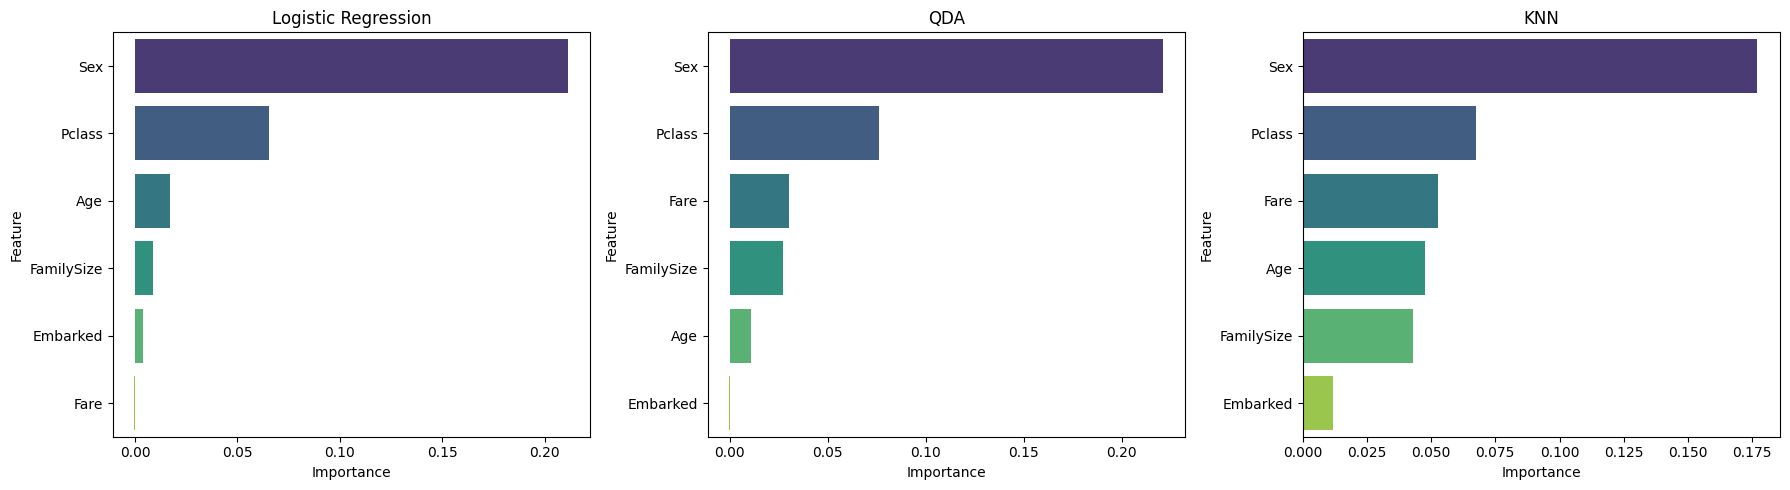

In [38]:
# Fit Logistic Regression
model_log.fit(X, y)
log_importance = permutation_importance(model_log, X, y, n_repeats=10, random_state=42)
log_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': log_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# Fit QDA
model_qda.fit(X, y)
qda_importance = permutation_importance(model_qda, X, y, n_repeats=10, random_state=42)
qda_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': qda_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# Fit KNN
model_knn.fit(X, y)
knn_importance = permutation_importance(model_knn, X, y, n_repeats=10, random_state=42)
knn_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': knn_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot all three side by side
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='Importance', y='Feature', data=log_df, palette='viridis')
plt.title('Logistic Regression')

plt.subplot(1, 3, 2)
sns.barplot(x='Importance', y='Feature', data=qda_df, palette='viridis')
plt.title('QDA')

plt.subplot(1, 3, 3)
sns.barplot(x='Importance', y='Feature', data=knn_df, palette='viridis')
plt.title('KNN')

plt.tight_layout()
plt.show()

Observing the feature importance charts, we note that the passenger's sex was far more important in predicting their survival, followed by their passenger class. 

### 6. Predictions

In [39]:
model_log.fit(X, y)
test_pred = model_log.predict(X_test)
submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": test_pred
})
submission.to_csv("logreg_titanic_submission.csv", index=False)

In [40]:
model_qda.fit(X, y)
test_pred = model_qda.predict(X_test)
submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": test_pred
})
submission.to_csv("qda_titanic_submission.csv", index=False)

In [41]:
model_knn.fit(X, y)
test_pred = model_knn.predict(X_test)
submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": test_pred
})
submission.to_csv("knn_titanic_submission.csv", index=False)

### 7. Discussion of model results in layman terms

We deployed three different classifier models to predict which passengers would survive the Titanic disaster, using these passenger features: ticket class, gender, age, fare paid, port of embarkation, and family size.

*Model Performance at a Glance*

All three models were about the same in terms of accuracy (~80%). However, the models had varying Precision and Recall rates.  Higher precision means that we would have fewer false positives, i.e., a passenger who did not survive would not be classified as a survivor. 

*Key Performance Differences*

Precision: Precision tells us "When the model predicts that a passenger survived, how often does it get that right?". On this metric:

1. KNN (k-Nearest Neighbors): Scored best at 78.1%, showing that it would be the most reliable model to predict passenger survival
2. QDA (Quadratic Discriminant Analysis): Scored 2nd best at 77.4%
3. Logistic Regression: Scored lowest at 75.7%, meaning it was not as reliable when predicting survival

Recall: Recall tells us: "Of those who survived, how many did we correctly identify?". Higher recall means we miss fewer survivors. 

1. Logistic Regression: Scored best at 69.9%, meaning it would identify the most number of survivors
2. KNN: Scored second best at 68.1%
3. QDA: Scored lowest at 66.9%, meaning it would miss a lot more survivors

*Trade-offs between the models*

1. Logistic Regression is better at catching actual survivors (high recall) but is not as good at predicting when someone will survive (low precision).
2. Conversely, KNN is better at predicting when someone will survive (high precision) but misses more people who actually survived (low recall)

Ultimately, model choice will depend on our prediction priorities. We recommend stakeholders to:
1. Choose Logistic Regression if it's more important to identify as many survivors as possible, even if it means some false positives
2. Choose KNN if it's more important to be confident in survival predictions, even if it means missing some actual survivors

## Appendix 2: Kaggle Profile and Submissions

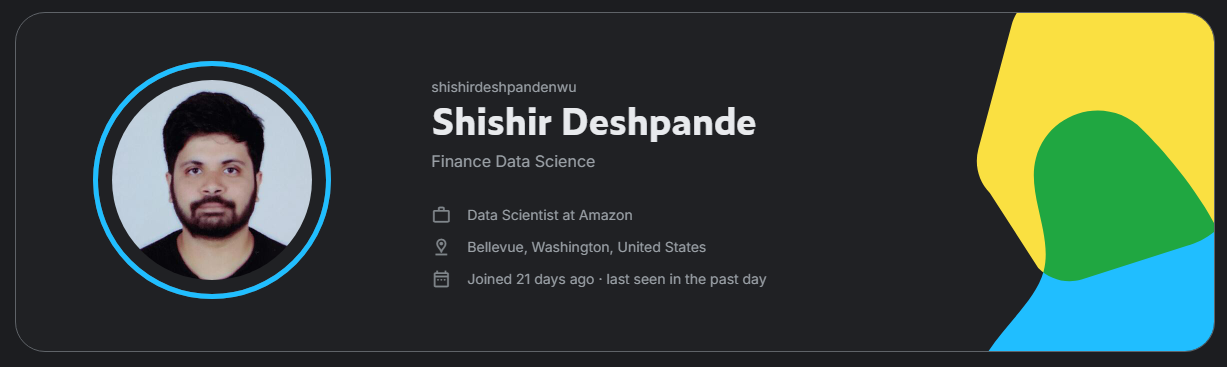

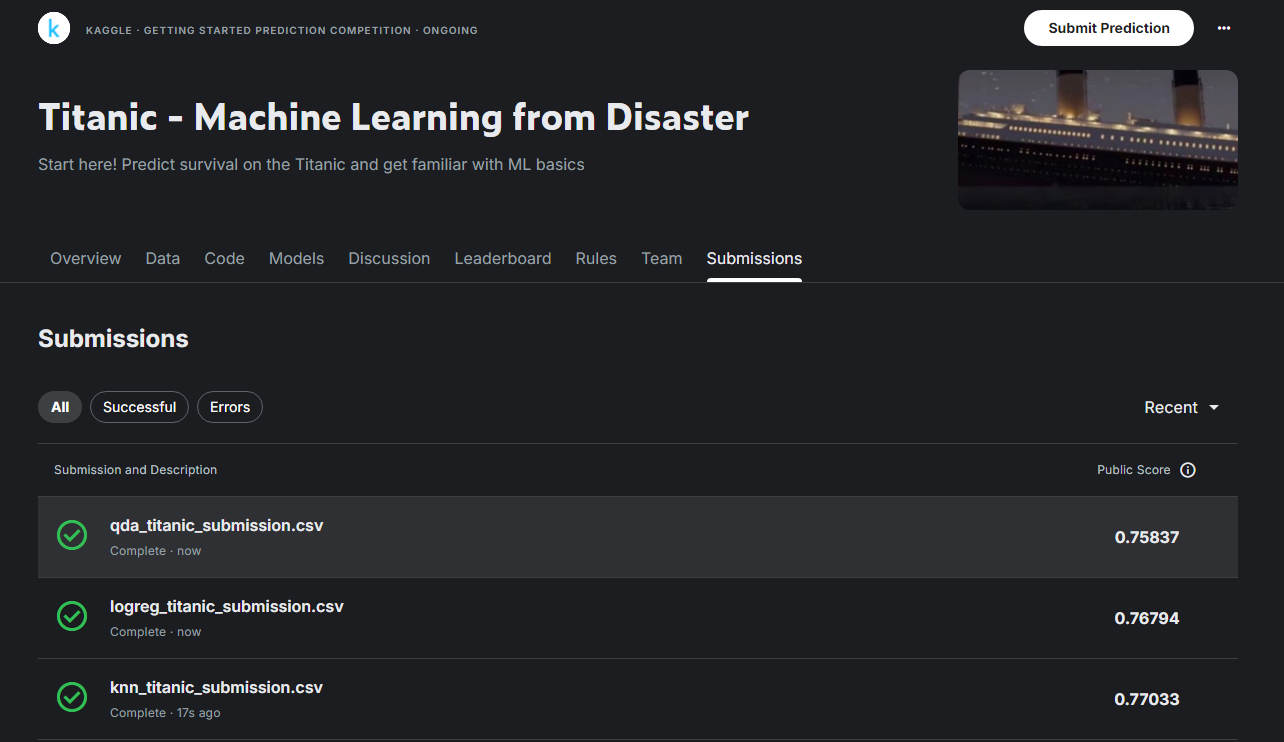